In [1]:
import torch.nn as nn
import os
import copy
import torch
import numpy as np
import wandb
import json
from datetime import datetime

from neuromancer.loggers import BasicLogger
import neuromancer.psl as psl
from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import ode, integrators
from torchgen.gen_functionalization_type import wrap_propagate_mutations_and_return

from SparseDPC.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.data.getdata import get_data, get_policy_data
from SparseDPC.trainer.trainer import SparseTrainer
from SparseDPC.utils.integrator import OneElementEulerIntegrator, FullStateEulerIntegrator, FullStateRK4Integrator
from SparseDPC.utils.utils import map_to_new_fx, save_model_with_timestamp
from SparseDPC.utils.loggers import CustomLogger

torch.manual_seed(86)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# device = torch.device('cpu')


In [2]:
# ground truth system model
gt_model = psl.nonautonomous.VanDerPolControl()
# sampling rate
ts = gt_model.params[1]['ts']
# problem dimensions
nx = gt_model.nx    # number of states
nu = gt_model.nu    # number of control inputs
nref = nx           # number of references
# constraints bounds
umin = -5.
umax = 5.
xmin = -5.
xmax = 5.



In [3]:
fx_models = [fx_library(i, nx=nx, nu=nu, seed=0, device=device,
                           max_degree=4, add_sqrt=False, add_u_prod=True) for i in range(nx)]
for fx in fx_models:
    print(fx)

dx0/dt = -0.004*x0 + 0.268*x1 + -0.412*x0^2 + -0.368*x0*x1 + -0.193*x1^2 + 0.134*x0^3 + -0.010*x0^2*x1 + 0.396*x0*x1^2 + -0.044*x1^3 + 0.132*x0^4 + -0.151*x0^3*x1 + -0.098*x0^2*x1^2 + -0.478*x0*x1^3 + -0.331*x1^4 + -0.206*u_0 + 0.019*x0*u_0 + 0.198*x1*u_0 

dx1/dt = -0.004*x1 + 0.268*x0 + -0.412*x0^2 + -0.368*x0*x1 + -0.193*x1^2 + 0.134*x0^3 + -0.010*x0^2*x1 + 0.396*x0*x1^2 + -0.044*x1^3 + 0.132*x0^4 + -0.151*x0^3*x1 + -0.098*x0^2*x1^2 + -0.478*x0*x1^3 + -0.331*x1^4 + -0.206*u_0 + 0.019*x0*u_0 + 0.198*x1*u_0 



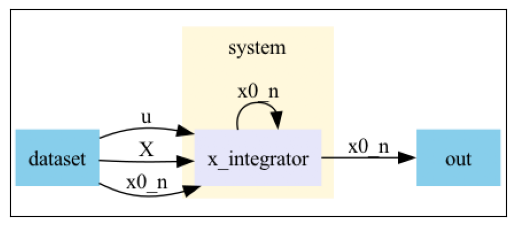

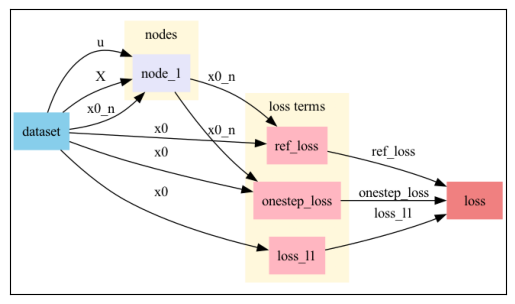

None
epoch: 0	train_loss: 15.93712	dev_loss: 7.15266	eltime:  0.71110
epoch: 100	train_loss: 0.03423	dev_loss: 0.27114	eltime:  4.66317
epoch: 200	train_loss: 0.00742	dev_loss: 0.24083	eltime:  8.07711
epoch: 300	train_loss: 0.00286	dev_loss: 0.07331	eltime:  11.22316
epoch: 400	train_loss: 0.00117	dev_loss: 0.02882	eltime:  14.13887

---------- Model 0 BEFORE pruning ----------
dx0/dt = -0.219*x0 + 0.865*x1 + -0.112*x0^2 + 0.113*x0*x1 + -0.007*x1^2 + 0.023*x0^3 + -0.032*x0^2*x1 + 0.020*x0*x1^2 + 0.012*x1^3 + 0.005*x0^4 + -0.070*x0^3*x1 + 0.116*x0^2*x1^2 + -0.051*x0*x1^3 + 0.005*x1^4 + 0.091*u_0 + 0.085*x0*u_0 + -0.057*x1*u_0 

   Threshold=0.11  Active=5  (prev=17)
   Pruned terms: ['x1^2', 'x0^3', 'x0^2*x1', 'x0*x1^2', 'x1^3', 'x0^4', 'x0^3*x1', 'x0*x1^3', 'x1^4', 'u_0', 'x0*u_0', 'x1*u_0']

⇒ Active-set changed; only adding small noise to surviving rows.

---------- Model 0 AFTER pruning  ----------
dx0/dt = -0.266*x0 + 0.776*x1 + -0.038*x0^2 + -0.144*x0*x1 + 0.103*x0^2*x1^2 

epoch

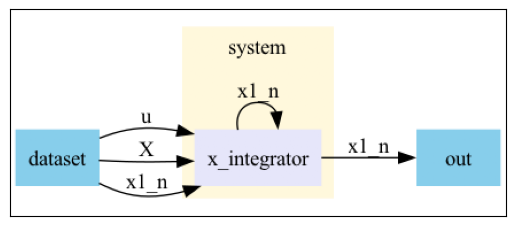

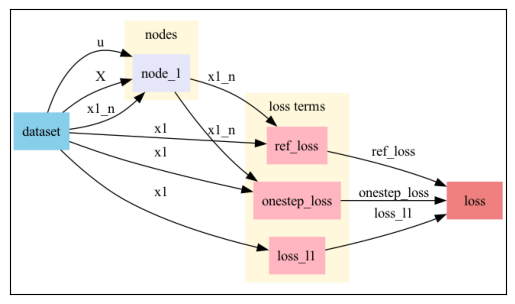

None
epoch: 0	train_loss: 1.38720	dev_loss: 43.84790	eltime:  0.54373
epoch: 100	train_loss: 0.03433	dev_loss: 0.04703	eltime:  3.76765
epoch: 200	train_loss: 0.02862	dev_loss: 0.04086	eltime:  7.01384
epoch: 300	train_loss: 0.00694	dev_loss: 0.00976	eltime:  10.22537
epoch: 400	train_loss: 0.00309	dev_loss: 0.00330	eltime:  13.41379

---------- Model 0 BEFORE pruning ----------
dx1/dt = 0.606*x1 + -0.828*x0 + -0.092*x0^2 + 0.079*x0*x1 + -0.035*x1^2 + -0.001*x0^3 + -0.720*x0^2*x1 + -0.183*x0*x1^2 + 0.030*x1^3 + 0.000*x0^4 + -0.052*x0^3*x1 + 0.130*x0^2*x1^2 + -0.061*x0*x1^3 + 0.007*x1^4 + 0.833*u_0 + 0.089*x0*u_0 + -0.026*x1*u_0 

   Threshold=0.11  Active=6  (prev=17)
   Pruned terms: ['x0^2', 'x0*x1', 'x1^2', 'x0^3', 'x1^3', 'x0^4', 'x0^3*x1', 'x0*x1^3', 'x1^4', 'x0*u_0', 'x1*u_0']

⇒ Active-set changed; only adding small noise to surviving rows.

---------- Model 0 AFTER pruning  ----------
dx1/dt = 0.695*x1 + -0.769*x0 + -0.671*x0^2*x1 + -0.310*x0*x1^2 + 0.142*x0^2*x1^2 + 0.957*u_0 

In [4]:
for i in range(nx):

    nsim = 2000   # number of simulation steps in the dataset
    nsteps = 2  # number of prediction horizon steps in the loss function
    bs = 100     # minibatching batch size
    train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

    integrator_x = OneElementEulerIntegrator(fx_models[i], h=ts)
    integrator_node_x = Node(integrator_x, ['X', f'x{i}_n', 'u'], [f'x{i}_n'], name="x_integrator")
    dynamics_model_x = System([integrator_node_x])

    dynamics_model_x.show()

    x = variable(f"x{i}")
    x_hat = variable(f'x{i}_n')[:, :-1, :]

    # Loss
    onestep_loss_x = 1.0 * ((x_hat[:, 1, :] == x[:, 1, :])^ 2)
    onestep_loss_x.name = "onestep_loss"

    reference_loss_x = 5. *((x_hat == x) ^ 2)
    reference_loss_x.name = "ref_loss"

    # Sparsity constraint
    l1_x = variable([x], lambda x: torch.norm(list(fx_models[i].parameters())[0], p=1))
    loss_l1_x = 1e-7 * (l1_x == 0)
    loss_l1_x.name = "loss_l1"

    objectives_x = [reference_loss_x, onestep_loss_x, loss_l1_x]
    loss_x = PenaltyLoss(objectives_x, [])
    problem_x = Problem([dynamics_model_x], loss_x)
    problem_x.show()

    lr = 1e-3
    optimizer_x = torch.optim.AdamW(problem_x.parameters(), lr=lr)

    logger = BasicLogger(args=None, savedir='test', verbosity=100,
                    stdout=['dev_loss', 'train_loss'])
    epochs=1500

    trainer_x = SparseTrainer(
        problem      = problem_x,
        fx_models  = [fx_models[i]],      # list of SINDy models
        lr           = 1e-3,
        train_data=None,
        test_data=None,
        optimizers=[optimizer_x],
        epochs=epochs,
        train_metric='train_loss',
        eval_metric='dev_loss',
        logger=logger,
        device=device,
        threshold=0.11,
        prune_every=500,
        warmup=300,
        patience=50,
        threshold_mult=1.05,
        )
    for _ in range(4):

        train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)
        trainer_x.train_data, trainer_x.dev_data = train_loader, dev_loader
        trainer_x.problem = problem_x  # Keep the problem consistent

        # Train control policy
        best_model = trainer_x.train()


        trainer_x.model.load_state_dict(best_model)

        # Update step size
        nsteps *= 2
        # trainer.model.loss.objectives[2].weight *= 1.1
        dynamics_model_x.nsteps = nsteps



In [5]:
for fx in fx_models:
    print(fx)

dx0/dt = 0.993*x1 

dx1/dt = 0.903*x1 + -0.980*x0 + -0.983*x0^2*x1 + 0.982*u_0 



In [6]:
integrator_x = FullStateRK4Integrator(fx_models, ts)          # custom step
x_integrator_node= Node(integrator_x,['xn', 'u'], ['xn'], name=f"x_integrator")


sindy_system = System(
    [x_integrator_node],
    nsteps=nsteps
)

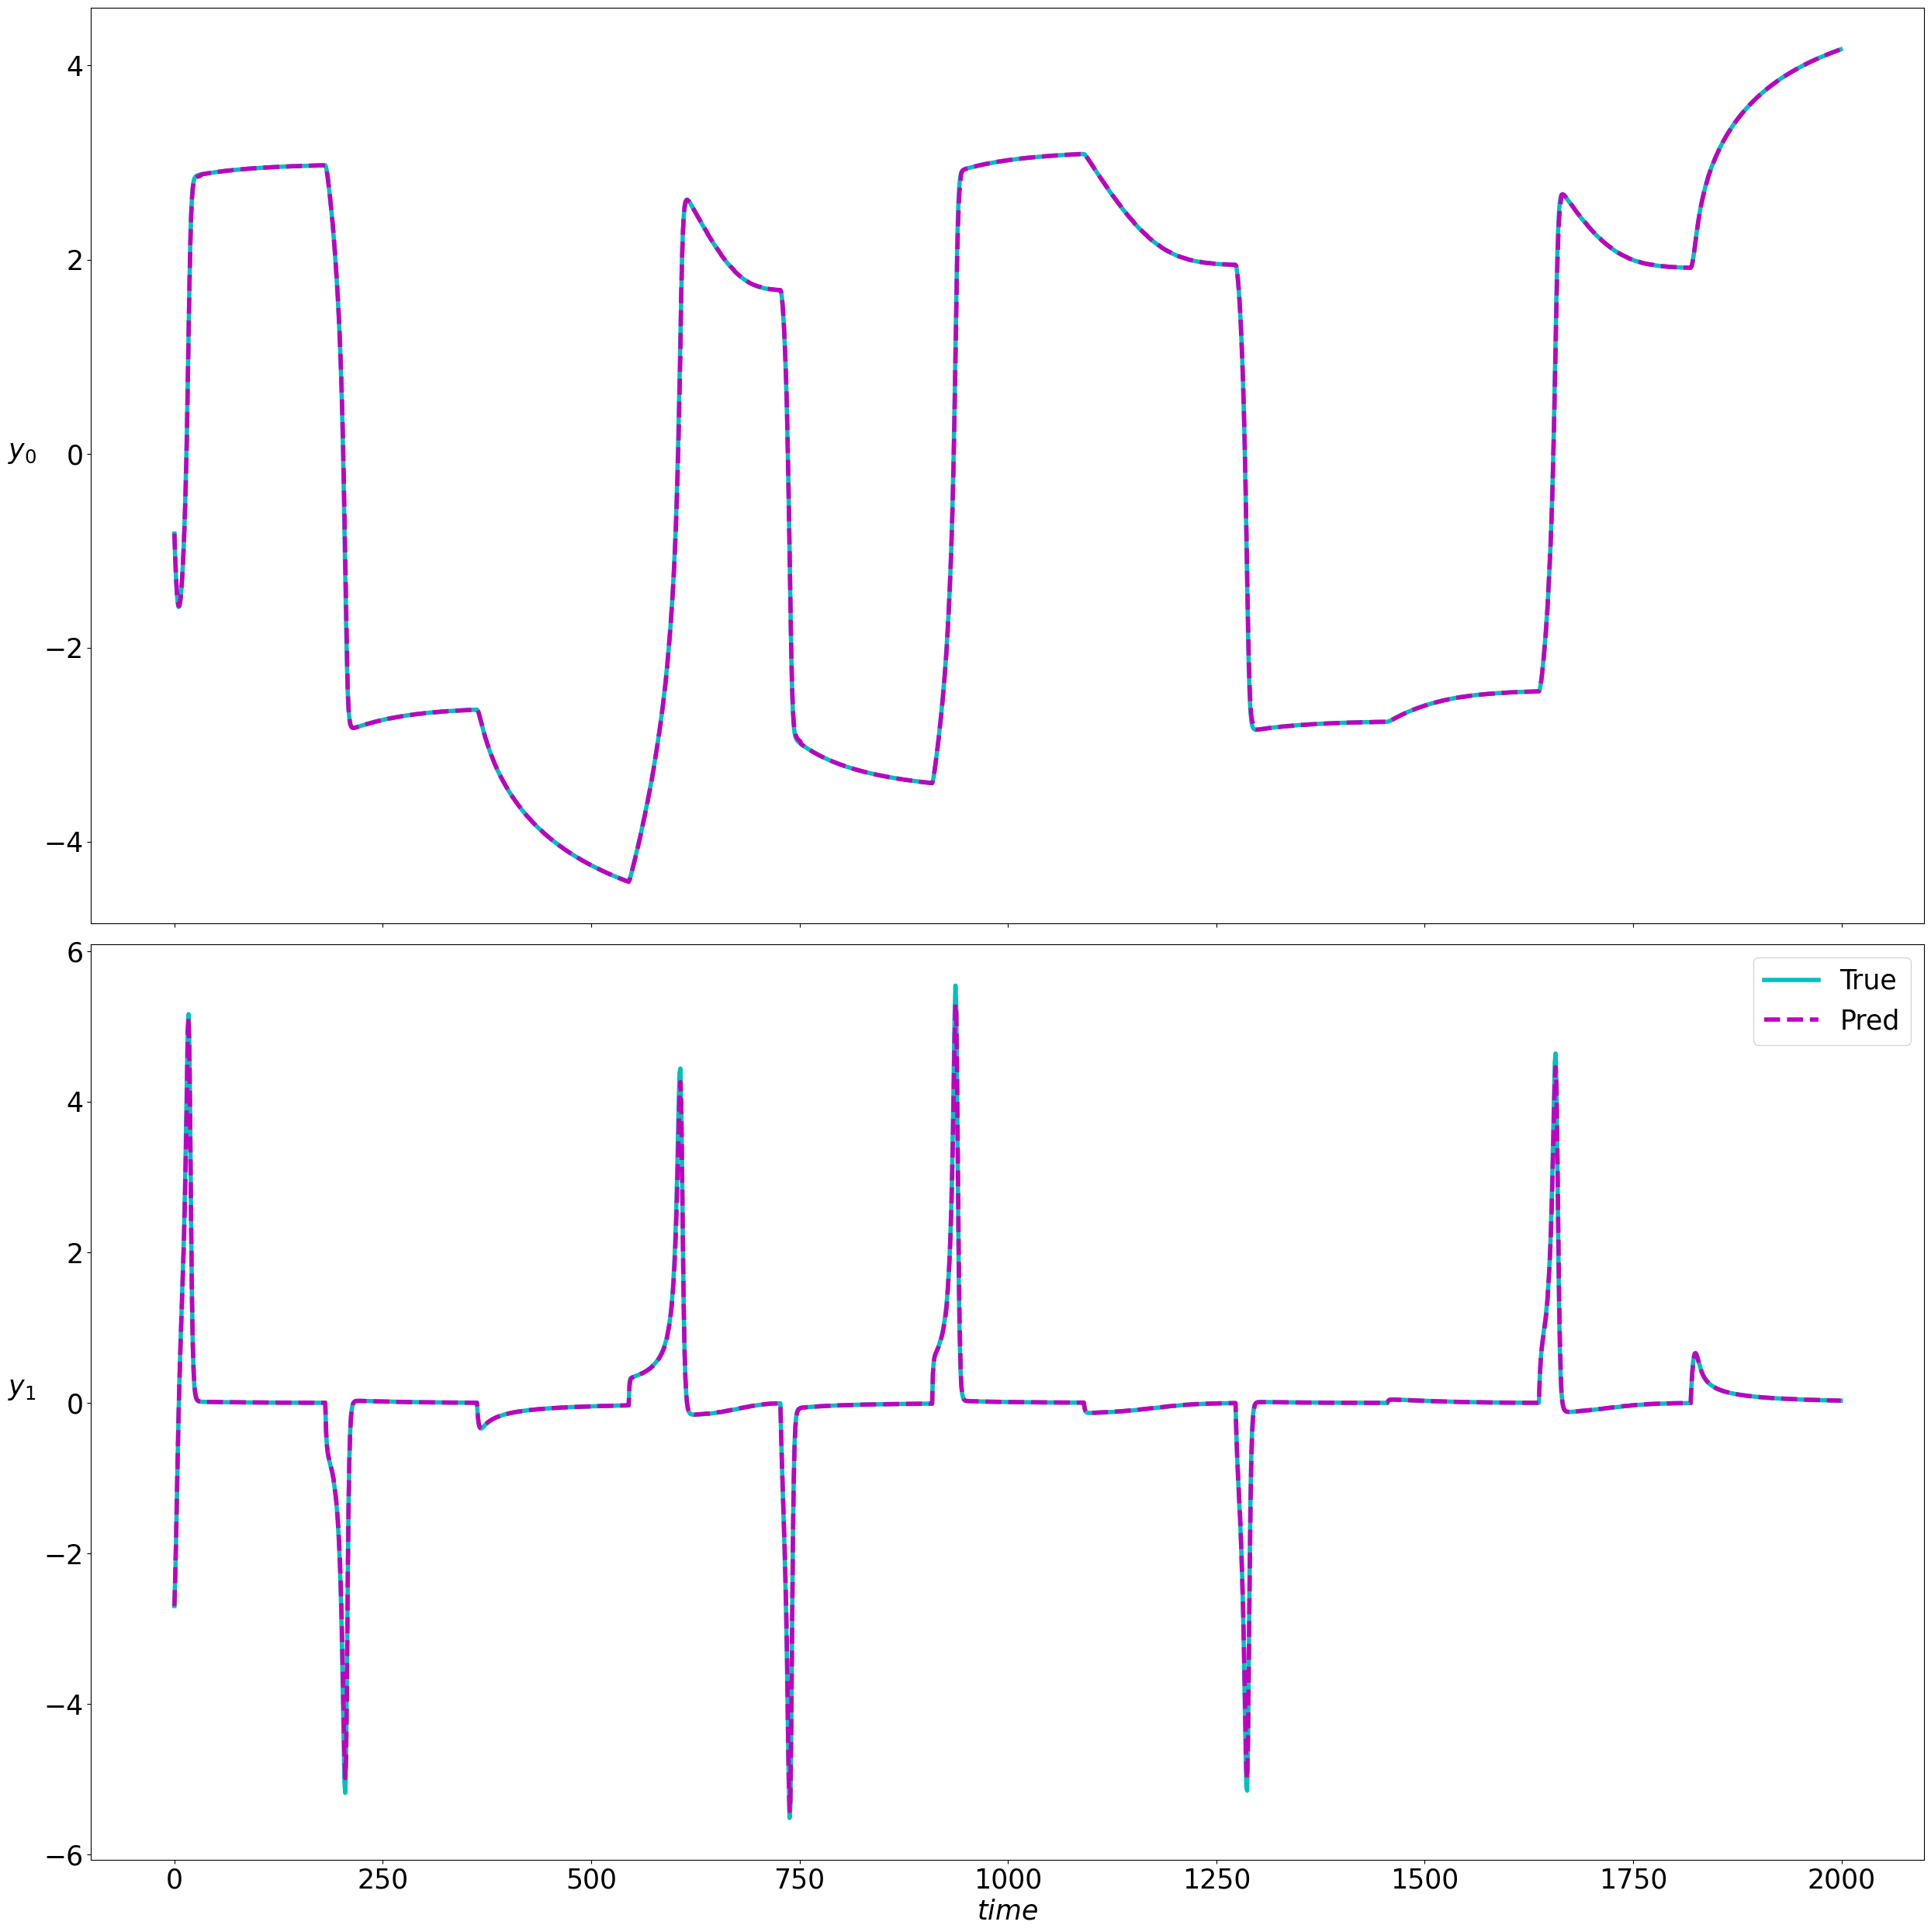

In [7]:
import matplotlib.pyplot as plt

sindy_system.nsteps = test_data['X'].shape[1]
test_output = sindy_system(test_data)

pred_traj = test_output['xn'][:, :-1, :]
true_traj = test_data['X']
pred_traj = pred_traj.detach().numpy().reshape(-1, nx)
true_traj = true_traj.detach().numpy().reshape(-1, nx)
pred_traj, true_traj = pred_traj.transpose(1, 0), true_traj.transpose(1, 0)

figsize = 25
fig, ax = plt.subplots(nx, figsize=(figsize, figsize))
labels = [f'$y_{k}$' for k in range(len(true_traj))]
for row, (t1, t2, label) in enumerate(zip(true_traj, pred_traj, labels)):
    if nx > 1:
        axe = ax[row]
    else:
        axe = ax
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1, 'c', linewidth=4.0, label='True')
    axe.plot(t2, 'm--', linewidth=4.0, label='Pred')
    axe.tick_params(labelbottom=False, labelsize=figsize)
axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)
axe.set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()

In [8]:
nsteps = 50  # prediction horizon
n_samples = 1500   # number of sampled scenarios
train_loader, dev_loader = get_policy_data(nsteps=nsteps,
                                           n_samples=n_samples,
                                           nx=nx,
                                           zero_refs=True,
                                           same_ref_for_all_states=True,
                                           device=device,
                                           batch_size=200,
                                           seed=22
                                           )

In [9]:
policies_seed = 5
fx_policies = [
            fx_policy_library(nx=nx, nref=0, policy_name=f"u_{i}", seed=policies_seed, device=device) for i in range(nu)
        ]

for fp in fx_policies:
    print(fp)

for fx in fx_models:
    print(fx)

u_0 = 0.330*x_0 + -0.374*x_1 + 0.407*sin(x_0) + 0.320*sin(x_1) + 0.420*cos(x_0) + -0.383*cos(x_1) + -0.336*sin(2*x_0) + 0.238*sin(2*x_1) + -0.467*cos(2*x_0) + 0.494*cos(2*x_1) + 0.106*x_0*sin(x_0) + 0.065*x_1*sin(x_1) + -0.428*x_0*cos(x_0) + 0.159*x_1*cos(x_1) + 0.215*x_0 * x_1 

dx0/dt = 0.993*x1 

dx1/dt = 0.903*x1 + -0.980*x0 + -0.983*x0^2*x1 + 0.982*u_0 



In [10]:
import json

# === Setup ===
nsteps = 50
session_id = datetime.now().strftime("%Y%m%d_%H%M%S")
session_folder = f"results/session_{session_id}"
os.makedirs(session_folder, exist_ok=True)

# === Base Configuration ===
base_config = {
    'reg_coef': 100.0,
    'l1_coef': 1e-2,
    'const_coef': 10.0,
    'lr': 5e-3,
    'epochs': 2499,
    'threshold': 0.1,
    'prune_every': 250,
    'threshold_mult': 1.1,
}
policies_seed = 5
l1_coef_list = [1e-2, 5e-3, 1e-3]
thresholds = [0.3, 0.2, 0.1, 0.05]

# === Run All Configurations ===
run_id = 0
for l1_coef in l1_coef_list:
    for threshold in thresholds:
        run_id += 1
        pol_configs = copy.deepcopy(base_config)
        pol_configs['threshold'] = threshold
        pol_configs['run_id'] = run_id

        run_name = f"VanDerPol_run{run_id}_l1coef{l1_coef}_th{threshold}"
        save_dir = os.path.join(session_folder, run_name)
        os.makedirs(save_dir, exist_ok=True)

        wandb.init(
            project="sindy-VanDerPol-multi-config",
            name=run_name,
            config=pol_configs,
            dir=save_dir,
            reinit=True
        )

        # === Policy Setup ===
        policies = [
            fx_policy_library(nx=nx, nref=0, policy_name=f"u_{i}", seed=policies_seed, device=device) for i in range(nu)
        ]

        policy_node = Node(
            lambda xn, r: torch.cat([torch.clamp(fp(xn, r), umin, umax) for fp in policies], dim=-1),
            ['xn', 'r'], ['u'], name="policy_combined"
        )

        integrator_x = FullStateEulerIntegrator(fx_models, ts)
        x_integrator_node = Node(integrator_x, ['xn', 'u'], ['xn'], name="x_integrator")
        sindy_system = System([policy_node, x_integrator_node], nsteps=nsteps)

        x = variable('xn')
        ref = variable('r')
        regulation_loss = pol_configs['reg_coef'] * ((x == ref) ^ 2)
        regulation_loss.name = "state_loss"

        loss_l1_policies = []
        for idx, fp in enumerate(policies):
            l1_raw = variable([x], lambda y, fp=fp: torch.norm(list(fp.parameters())[0], p=1), display_name=f"l1_policy{idx}")
            l1_pen = l1_coef * (l1_raw == 0)
            l1_pen.name = f"loss_l1_policy_{idx}"
            loss_l1_policies.append(l1_pen)

        c = pol_configs['const_coef']
        state_lower = c * (x > xmin); state_lower.name = "x_min"
        state_upper = c * (x < xmax); state_upper.name = "x_max"
        term_lower = c * (x[:, [-1], :] > ref - 0.01); term_lower.name = "y_N_min"
        term_upper = c * (x[:, [-1], :] < ref + 0.01); term_upper.name = "y_N_max"

        objectives = [regulation_loss, *loss_l1_policies]
        constraints = [state_lower, state_upper, term_lower, term_upper]
        loss = PenaltyLoss(objectives, constraints)
        problem = Problem([sindy_system], loss)

        logger = CustomLogger(
            args=None,
            save_dir=save_dir,
            verbosity=10,
            stdout=['train_loss', 'dev_loss'],
            fx_policies=policies,
            pol_configs=pol_configs
        )

        trainer_policy = SparseTrainer(
            problem=problem,
            fx_models=policies,
            lr=pol_configs['lr'],
            train_data=train_loader,
            dev_data=dev_loader,
            optimizers=[torch.optim.AdamW(fp.parameters(), lr=pol_configs['lr']) for fp in policies],
            epochs=pol_configs['epochs'],
            train_metric='train_loss',
            eval_metric='dev_loss',
            logger=logger,
            device=device,
            threshold=pol_configs['threshold'],
            prune_every=pol_configs['prune_every'],
            threshold_mult=pol_configs['threshold_mult']
        )

        best_state = trainer_policy.train()
        # === Save final coefficients
        for i, fp in enumerate(policies):
            coef = fp.coef.detach().cpu().numpy()
            np.savetxt(f"{save_dir}/policy{i}_final.csv", coef, delimiter=",")
            wandb.log({f"final_active_terms_policy_{i}": int(np.count_nonzero(coef))})

        # === Save mapped models
        models_dir = os.path.join(save_dir, "saved_models")
        os.makedirs(models_dir, exist_ok=True)

        # Create corresponding master policies and save the mapped models
        for i in range(nu):
            policy_name = f"u_{i}"

            # Create a base fx policy (untrained) to map to full library
            policy_base = fx_policy_library(
                nx=nx, nref=1, policy_name=policy_name, seed=policies_seed, device=device
            )

            # Map trained policy to full library structure
            policy_mapped = map_to_new_fx(policies[i], policy_base)

            # Save the mapped model
            save_model_with_timestamp(policy_mapped, f"trained_policy_{i}", models_dir)

        with open(os.path.join(save_dir, "run_config.json"), "w") as f:
            json.dump(pol_configs, f, indent=4)

        wandb.finish()

# === Save session metadata ===
with open(os.path.join(session_folder, "session_config.txt"), "w") as f:
    f.write(f"Session ID: {session_id}\n")
    f.write(f"Started at: {datetime.now()}\n")
    f.write(f"Total runs: {run_id}\n")
    f.write(f"L1 Coef List: {l1_coef_list}\n")
    f.write(f"Thresholds: {thresholds}\n")


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: alirezad126 (alirezad126-johns-hopkins-university). Use `wandb login --relogin` to force relogin


None
epoch: 0	train_loss: 103.05532	dev_loss: 104.47966	eltime:  0.54205
epoch: 10	train_loss: 18.30334	dev_loss: 18.36873	eltime:  5.95901
epoch: 20	train_loss: 12.10396	dev_loss: 12.24163	eltime:  11.60907
epoch: 30	train_loss: 9.78917	dev_loss: 9.90750	eltime:  17.16053
epoch: 40	train_loss: 8.63737	dev_loss: 8.73466	eltime:  22.86044
epoch: 50	train_loss: 7.96593	dev_loss: 8.04918	eltime:  28.62832
epoch: 60	train_loss: 7.52824	dev_loss: 7.60264	eltime:  34.37305
epoch: 70	train_loss: 7.21799	dev_loss: 7.28570	eltime:  40.11548
epoch: 80	train_loss: 6.98311	dev_loss: 7.04597	eltime:  46.10391
epoch: 90	train_loss: 6.79590	dev_loss: 6.85406	eltime:  51.95274
epoch: 100	train_loss: 6.64112	dev_loss: 6.69512	eltime:  57.71237
epoch: 110	train_loss: 6.50910	dev_loss: 6.55965	eltime:  63.44571
epoch: 120	train_loss: 6.39382	dev_loss: 6.44134	eltime:  69.17579
epoch: 130	train_loss: 6.29215	dev_loss: 6.33699	eltime:  74.90259
epoch: 140	train_loss: 6.20160	dev_loss: 6.24402	eltime:  80.6

active_terms_policy_0,█▅▄▁▁▁▁▁▁▁
dev_loss,▇▄▄▄█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇██
final_active_terms_policy_0,▁
train_loss,█▅▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
active_terms_policy_0,4
dev_loss,5.27422
epoch,2498
final_active_terms_policy_0,4
train_loss,5.25085


None
epoch: 0	train_loss: 103.05532	dev_loss: 104.47966	eltime:  0.65932
epoch: 10	train_loss: 18.30334	dev_loss: 18.36873	eltime:  7.49127
epoch: 20	train_loss: 12.10396	dev_loss: 12.24163	eltime:  14.24223
epoch: 30	train_loss: 9.78917	dev_loss: 9.90750	eltime:  21.06659
epoch: 40	train_loss: 8.63737	dev_loss: 8.73466	eltime:  27.83096
epoch: 50	train_loss: 7.96593	dev_loss: 8.04918	eltime:  34.84409
epoch: 60	train_loss: 7.52824	dev_loss: 7.60264	eltime:  41.64470
epoch: 70	train_loss: 7.21799	dev_loss: 7.28570	eltime:  48.34580
epoch: 80	train_loss: 6.98311	dev_loss: 7.04597	eltime:  55.12155
epoch: 90	train_loss: 6.79590	dev_loss: 6.85406	eltime:  62.04687
epoch: 100	train_loss: 6.64112	dev_loss: 6.69512	eltime:  68.65688
epoch: 110	train_loss: 6.50910	dev_loss: 6.55965	eltime:  75.48053
epoch: 120	train_loss: 6.39382	dev_loss: 6.44134	eltime:  82.27556
epoch: 130	train_loss: 6.29215	dev_loss: 6.33699	eltime:  89.22324
epoch: 140	train_loss: 6.20160	dev_loss: 6.24402	eltime:  95.9

active_terms_policy_0,█▅▄▂▂▂▂▁▁▁
dev_loss,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇█
final_active_terms_policy_0,▁
train_loss,█▇▃▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
active_terms_policy_0,5
dev_loss,5.27284
epoch,2498
final_active_terms_policy_0,5
train_loss,5.24864


...

active_terms_policy_0,█▇▅▁▁▁▁▁▁▁
dev_loss,█▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇█
final_active_terms_policy_0,▁
train_loss,█▇▅▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
active_terms_policy_0,4
dev_loss,5.19709
epoch,2498
final_active_terms_policy_0,4
train_loss,5.1725


None
epoch: 0	train_loss: 103.03284	dev_loss: 104.45749	eltime:  0.96453
epoch: 10	train_loss: 18.28193	dev_loss: 18.34732	eltime:  9.99949
epoch: 20	train_loss: 12.07997	dev_loss: 12.21760	eltime:  18.82520
epoch: 30	train_loss: 9.76330	dev_loss: 9.88158	eltime:  27.68396
epoch: 40	train_loss: 8.61022	dev_loss: 8.70746	eltime:  36.49091
epoch: 50	train_loss: 7.93777	dev_loss: 8.02098	eltime:  45.45877
epoch: 60	train_loss: 7.49926	dev_loss: 7.57361	eltime:  54.29852
epoch: 70	train_loss: 7.18829	dev_loss: 7.25596	eltime:  63.10329
epoch: 80	train_loss: 6.95273	dev_loss: 7.01554	eltime:  72.17269
epoch: 90	train_loss: 6.76486	dev_loss: 6.82296	eltime:  81.03268
epoch: 100	train_loss: 6.60907	dev_loss: 6.66299	eltime:  89.86219
epoch: 110	train_loss: 6.47603	dev_loss: 6.52650	eltime:  98.76817
epoch: 120	train_loss: 6.35979	dev_loss: 6.40724	eltime:  108.02873
epoch: 130	train_loss: 6.25708	dev_loss: 6.30184	eltime:  117.06305
epoch: 140	train_loss: 6.16547	dev_loss: 6.20781	eltime:  12

active_terms_policy_0,█▇▆▂▁▁▁▁▁▁
dev_loss,█▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▁▁▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇███
final_active_terms_policy_0,▁
train_loss,█▅▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
active_terms_policy_0,4
dev_loss,5.19709
epoch,2498
final_active_terms_policy_0,4
train_loss,5.1725


None
epoch: 0	train_loss: 103.01487	dev_loss: 104.43975	eltime:  1.02411
epoch: 10	train_loss: 18.26534	dev_loss: 18.33072	eltime:  10.38495
epoch: 20	train_loss: 12.06080	dev_loss: 12.19839	eltime:  20.02372
epoch: 30	train_loss: 9.74255	dev_loss: 9.86078	eltime:  34.09706
epoch: 40	train_loss: 8.58839	dev_loss: 8.68559	eltime:  47.06293
epoch: 50	train_loss: 7.91512	dev_loss: 7.99829	eltime:  57.85713
epoch: 60	train_loss: 7.47594	dev_loss: 7.55026	eltime:  67.57206
epoch: 70	train_loss: 7.16439	dev_loss: 7.23203	eltime:  77.87605
epoch: 80	train_loss: 6.92827	dev_loss: 6.99104	eltime:  87.93268
epoch: 90	train_loss: 6.73986	dev_loss: 6.79790	eltime:  98.00639
epoch: 100	train_loss: 6.58329	dev_loss: 6.63714	eltime:  107.96784
epoch: 110	train_loss: 6.44940	dev_loss: 6.49981	eltime:  117.76731
epoch: 120	train_loss: 6.33237	dev_loss: 6.37976	eltime:  127.83973
epoch: 130	train_loss: 6.22884	dev_loss: 6.27354	eltime:  137.59786
epoch: 140	train_loss: 6.13635	dev_loss: 6.17863	eltime: 


KeyboardInterrupt



In [ ]:
# import os
# import copy
# import torch
# import numpy as np
# import wandb
# from datetime import datetime
#
# # Create a unique session folder based on timestamp (or manually set one)
# session_id = datetime.now().strftime("%Y%m%d_%H%M%S")
# session_folder = f"results/session_{session_id}"
# os.makedirs(session_folder, exist_ok=True)
#
# # Base config
# base_config = {
#     'reg_coef': 100.0,
#     'l1_coef': 1e-2,
#     'const_coef': 20.0,
#     'lr': 1e-2,
#     'epochs': 1500,
#     'threshold': 0.1,
#     'prune_every': 150,
#     'threshold_mult': 1.1,
# }
# policies_seed=5
# # All variations
# l1_coef_list = [5e-2, 1e-2, 5e-3, 1e-3]
# thresholds = [0.3, 0.2, 0.1, 0.05]
#
# run_id = 0
# for l1_coef in l1_coef_list:
#     for threshold in thresholds:
#         run_id += 1
#         pol_configs = copy.deepcopy(base_config)
#         pol_configs['threshold'] = threshold
#         pol_configs['run_id'] = run_id
#
#         run_name = f"VanDerPol_run{run_id}_l1coef{l1_coef}_th{threshold}"
#         save_dir = os.path.join(session_folder, run_name)
#         os.makedirs(save_dir, exist_ok=True)
#
#         # Initialize W&B for this run
#         wandb.init(
#             project="sindy-VanDerPol-multi-config",
#             name=run_name,
#             config=pol_configs,
#             dir=save_dir,
#             reinit=True
#         )
#
#         fx_policies = [fx_policy_library(nx=2, nref=1, policy_name= "u",
#                                          seed=policies_seed, device=device)]
#
#         policy_node = Node(
#             lambda xn, r: torch.cat([torch.clamp(fp(xn, r), umin, umax) for fp in fx_policies], dim=-1),
#             ['xn', 'r'], ['u'], name="policy_combined"
#         )
#
#         integrator_x = FullStateEulerIntegrator(fx_models, ts)
#         x_integrator_node = Node(integrator_x, ['xn', 'u'], ['xn'], name="x_integrator")
#         sindy_system = System([policy_node, x_integrator_node], nsteps=nsteps)
#
#         x = variable('xn')
#         ref = variable('r')
#         regulation_loss = pol_configs['reg_coef'] * ((x == ref) ^ 2)
#         regulation_loss.name = "state_loss"
#
#         loss_l1_policies = []
#         for idx, fp in enumerate(fx_policies):
#             l1_raw = variable([x], lambda y, fp=fp: torch.norm(list(fp.parameters())[0], p=1), display_name=f"l1_policy{idx}")
#             l1_pen = l1_coef * (l1_raw == 0)
#             l1_pen.name = f"loss_l1_policy_{idx}"
#             loss_l1_policies.append(l1_pen)
#
#         c = pol_configs['const_coef']
#         state_lower = c * (x > xmin); state_lower.name = "x_min"
#         state_upper = c * (x < xmax); state_upper.name = "x_max"
#         term_lower = c * (x[:, [-1], :] > ref - 0.01); term_lower.name = "y_N_min"
#         term_upper = c * (x[:, [-1], :] < ref + 0.01); term_upper.name = "y_N_max"
#
#         objectives = [regulation_loss, *loss_l1_policies]
#         constraints = [state_lower, state_upper, term_lower, term_upper]
#         loss = PenaltyLoss(objectives, constraints)
#         problem = Problem([sindy_system], loss)
#
#         logger = CustomLogger(
#             args=None,
#             save_dir=save_dir,
#             verbosity=10,
#             stdout=['train_loss', 'dev_loss'],
#             fx_policies=fx_policies,
#             pol_configs=pol_configs
#         )
#
#         trainer_policy = SparseTrainer(
#             problem=problem,
#             fx_models=fx_policies,
#             lr=pol_configs['lr'],
#             train_data=train_loader,
#             dev_data=dev_loader,
#             optimizers=[torch.optim.AdamW(fp.parameters(), lr=pol_configs['lr']) for fp in fx_policies],
#             epochs=pol_configs['epochs'],
#             train_metric='train_loss',
#             eval_metric='dev_loss',
#             logger=logger,
#             device=device,
#             threshold=pol_configs['threshold'],
#             prune_every=pol_configs['prune_every'],
#             threshold_mult=pol_configs['threshold_mult']
#         )
#
#         best_state = trainer_policy.train()
#         trainer_policy.model.load_state_dict(best_state)
#
#         for i, fp in enumerate(fx_policies):
#             coef = fp.coef.detach().cpu().numpy()
#             np.savetxt(f"{save_dir}/policy{i}_final.csv", coef, delimiter=",")
#             wandb.log({f"final_active_terms_policy_{i}": int(np.count_nonzero(coef))})
#
#         wandb.finish()
#
#
#
# # ========================
# # 5. Save session metadata
# # ========================
# with open(os.path.join(session_folder, "session_config.txt"), "w") as f:
#     f.write(f"Session ID: {session_id}\n")
#     f.write(f"Started at: {datetime.now()}\n")
#     f.write(f"Total runs: {run_id}\n")
#     f.write(f"L1 Coef List: {l1_coef_list}\n")
#     f.write(f"Thresholds: {thresholds}\n")


In [ ]:

# ------------------------------------------------------------------ #
# 0.  Combined policy (any #policies)
# ------------------------------------------------------------------ #
policy_node = Node(
    lambda xn, r: torch.cat(
        [torch.clamp(fp(xn, r), umin, umax)  # capture fp by value
         for fp in fx_policies],
        dim=-1),
    ['xn', 'r'], ['u'],
    name="policy_combined"
)

# ------------------------------------------------------------------ #
# build integrator node and system
# ------------------------------------------------------------------ #

integrator_x = FullStateEulerIntegrator(fx_models, ts)
x_integrator_node= Node(integrator_x,['xn', 'u'], ['xn'], name=f"x_integrator")
sindy_system = System(
    [policy_node, x_integrator_node],
    nsteps=nsteps
)

# ------------------------------------------------------------------ #
# 4.  Objectives
# ------------------------------------------------------------------ #
x   = variable('xn')
ref = variable('r')

regulation_loss      = pol_configs['reg_coef'] * ((x == ref) ^ 2); regulation_loss.name = "state_loss"

#   L1 sparsity for each policy
loss_l1_policies = []
for idx, fp in enumerate(fx_policies):
    l1_raw  = variable([x],
                       lambda y, fp=fp: torch.norm(list(fp.parameters())[0], p=1),
                       display_name=f"l1_policy{idx}")
    l1_pen  = pol_configs['l1_coef'] * (l1_raw == 0)
    l1_pen.name = f"loss_l1_policy_{idx}"
    loss_l1_policies.append(l1_pen)

# ------------------------------------------------------------------ #
# 5.  Constraints
# ------------------------------------------------------------------ #
state_lower  = pol_configs['const_coef'] * (x > xmin);           state_lower.name  = "x_min"
state_upper  = pol_configs['const_coef'] * (x < xmax);           state_upper.name  = "x_max"
term_lower   = pol_configs['const_coef'] * (x[:, [-1], :] > ref - 0.01); term_lower.name = "y_N_min"
term_upper   = pol_configs['const_coef'] * (x[:, [-1], :] < ref + 0.01); term_upper.name = "y_N_max"

# ------------------------------------------------------------------ #
# 6.  Problem definition
# ------------------------------------------------------------------ #
objectives  = [regulation_loss, *loss_l1_policies]
constraints = [state_lower, state_upper, term_lower, term_upper]

loss     = PenaltyLoss(objectives, constraints)
problem  = Problem([sindy_system], loss)
problem.show()

# ------------------------------------------------------------------ #
# 7.  Optimiser & trainer
# ------------------------------------------------------------------ #
lr         = pol_configs['lr']
optimizers = [torch.optim.AdamW(fp.parameters(), lr=lr) for fp in fx_policies]

trainer_policy = SparseTrainer(
    problem     = problem,
    fx_models   = fx_policies,
    lr          = lr,
    train_data  = train_loader,
    dev_data    = dev_loader,
    optimizers  = optimizers,
    epochs      = pol_configs['epochs'],
    train_metric='train_loss',
    eval_metric ='dev_loss',
    logger      = WandbLogger(
                                args=None,
                                savedir='test',
                                verbosity=1,
                                stdout=['dev_loss', 'train_loss'],
                                fx_policies=fx_policies
                            ),
    device      = device,
    threshold   = pol_configs['threshold'],
    prune_every = pol_configs['prune_every'],
    threshold_mult=pol_configs['threshold_mult']
)

print(f"*** training with {nsteps} steps ***")
best_state = trainer_policy.train()
trainer_policy.model.load_state_dict(best_state)

for i, fp in enumerate(fx_policies):
    print(f"Policy {i}:\n{fp}\n")


In [ ]:
# white-box
policy_node = Node(
    lambda xn, r: torch.cat(
        [torch.clamp(fp(xn, r), umin, umax).to(torch.device('cpu'))  # capture fp by value
         for fp in fx_policies],
        dim=-1),
    ['xn', 'r'], ['u'],
    name="policy_combined"
)


# ODE model with no-plant model mismatch
van_der_pol = ode.VanDerPolControl()                   # ODE system equations implemented in PyTorch
# integrate continuous time ODE
gt_integrator = integrators.RK4(van_der_pol, h=torch.tensor(ts))   # using 4th order runge kutta integrator
# symbolic system model
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

import copy
gt_sindy_policy = copy.deepcopy(System([policy_node,
                       gt_integrator_node]))
gt_sindy_policy.show()

In [ ]:
import numpy as np
from neuromancer.plot import pltCL, pltPhase

nsteps = 100
seed = 52
torch.manual_seed(seed)

# Generate reference signal
xn_test = torch.rand(1, 1, nx, dtype=torch.float32)

# Initial data
data = {
    'xn': xn_test.to(device),
    'x1_n': xn_test[:, :, 0:1].to(device),
    'x2_n': xn_test[:, :, 1:2].to(device),
    'r': torch.zeros(1, nsteps+1, nx, dtype=torch.float32).to(device)
}
gt_sindy_policy.nsteps = nsteps
# perform closed-loop simulation
trajectories_before_adaptation = gt_sindy_policy(data)

# constraints bounds
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])
# plot closed loop trajectories
pltCL(Y=trajectories_before_adaptation['xn'].detach().cpu().reshape(nsteps + 1, nx),
      R=trajectories_before_adaptation['r'].detach().cpu().reshape(nsteps + 1, nref),
      U=trajectories_before_adaptation['u'].detach().cpu().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=-1., Ymax=1.)

In [ ]:
van_der_pol